# Hypothesis Testing 

In [ ]:
import pandas as pd
from sklearn.utils import resample
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df = pd.read_csv('vertebrate.csv')
df

,Name,Warm-blooded,Gives Birth,Aquatic Creature,Aerial Creature,Has Legs,Hibernates,Class
0,human,1,1,0,0,1,0,mammals
1,python,0,0,0,0,0,1,reptiles
2,salmon,0,0,1,0,0,0,fishes
3,whale,1,1,1,0,0,0,mammals
4,frog,0,0,1,0,1,1,amphibians
5,komodo,0,0,0,0,1,0,reptiles
6,bat,1,1,0,1,1,1,mammals
7,pigeon,1,0,0,1,1,0,birds
8,cat,1,1,0,0,1,0,mammals
9,leopard shark,0,1,1,0,0,0,fishes


In [25]:
df.shape

(15, 8)

# Bootstrap Sampling

In [ ]:
# bootstrap sample half the data
sample = resample(df, n_samples=int(df.shape[0] * 0.5))
sample

,Name,Warm-blooded,Gives Birth,Aquatic Creature,Aerial Creature,Has Legs,Hibernates,Class
1,python,0,0,0,0,0,1,reptiles
10,turtle,0,0,1,0,1,0,reptiles
7,pigeon,1,0,0,1,1,0,birds
0,human,1,1,0,0,1,0,mammals
9,leopard shark,0,1,1,0,0,0,fishes
0,human,1,1,0,0,1,0,mammals
10,turtle,0,0,1,0,1,0,reptiles


In [27]:
sample.loc[sample.duplicated(), :]

,Name,Warm-blooded,Gives Birth,Aquatic Creature,Aerial Creature,Has Legs,Hibernates,Class
0,human,1,1,0,0,1,0,mammals
10,turtle,0,0,1,0,1,0,reptiles


In [28]:
sample2 = resample(df, n_samples=int(df.shape[0] * 0.5), replace=False)
sample2

,Name,Warm-blooded,Gives Birth,Aquatic Creature,Aerial Creature,Has Legs,Hibernates,Class
9,leopard shark,0,1,1,0,0,0,fishes
10,turtle,0,0,1,0,1,0,reptiles
5,komodo,0,0,0,0,1,0,reptiles
2,salmon,0,0,1,0,0,0,fishes
13,eel,0,0,1,0,0,0,fishes
12,porcupine,1,1,0,0,1,1,mammals
11,penguin,1,0,1,0,1,0,birds


# Permutation Test


After an A/B test, A and B's results are shown. Both size = 60.

A was control, B was new choice.


One way hypothesis test:


 Null hypothesis: A = B


 Alternate hypothesis: B > A 

In [29]:
A = np.array([
    52, 48, 55, 50, 49, 53, 51, 47, 54, 52,
    46, 50, 49, 51, 48, 52, 53, 47, 50, 49,
    54, 55, 51, 52, 48, 49, 50, 53, 47, 46,
    52, 54, 51, 49, 50, 48, 47, 53, 55, 52,
    49, 50, 51, 48, 46, 47, 52, 53, 54, 50,
    49, 51, 48, 47, 52, 53, 50, 49, 51, 48
])

B = np.array([
    56, 54, 58, 55, 57, 59, 56, 54, 57, 58,
    55, 56, 54, 57, 58, 59, 55, 56, 54, 57,
    58, 60, 59, 56, 55, 54, 57, 58, 56, 55,
    59, 60, 58, 57, 56, 55, 54, 59, 60, 58,
    57, 56, 55, 54, 58, 59, 57, 56, 55, 54,
    59, 60, 58, 57, 56, 55, 54, 59, 58, 57
])


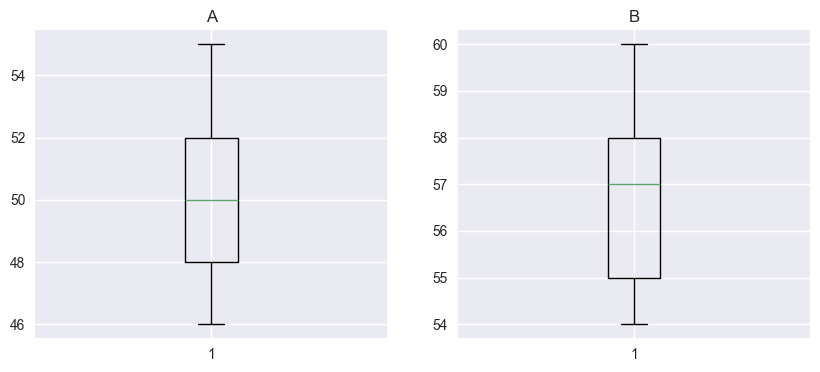

In [41]:
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(1, 2, figsize=(10,4))

axes[0].boxplot(A)
axes[1].boxplot(B)
axes[0].set_title('A')
axes[1].set_title('B')
plt.show()


In [31]:
len(A)==len(B), len(A)

(True, 60)

In [32]:
# Observed difference

obs_diff = B.mean() - A.mean()
obs_diff

np.float64(6.383333333333333)

In [33]:
combined = np.concatenate([A, B])
combined

array([52, 48, 55, 50, 49, 53, 51, 47, 54, 52, 46, 50, 49, 51, 48, 52, 53,
       47, 50, 49, 54, 55, 51, 52, 48, 49, 50, 53, 47, 46, 52, 54, 51, 49,
       50, 48, 47, 53, 55, 52, 49, 50, 51, 48, 46, 47, 52, 53, 54, 50, 49,
       51, 48, 47, 52, 53, 50, 49, 51, 48, 56, 54, 58, 55, 57, 59, 56, 54,
       57, 58, 55, 56, 54, 57, 58, 59, 55, 56, 54, 57, 58, 60, 59, 56, 55,
       54, 57, 58, 56, 55, 59, 60, 58, 57, 56, 55, 54, 59, 60, 58, 57, 56,
       55, 54, 58, 59, 57, 56, 55, 54, 59, 60, 58, 57, 56, 55, 54, 59, 58,
       57])

In [34]:
n_perms = 100
perms_diffs = []

for _ in range(n_perms):
    shuffled = np.random.permutation(combined)
    A_perm = shuffled[:len(A)]
    B_perm = shuffled[len(A):]
    perms_diffs.append(B_perm.mean() - A_perm.mean())
    
perms_diffs = np.array(perms_diffs)

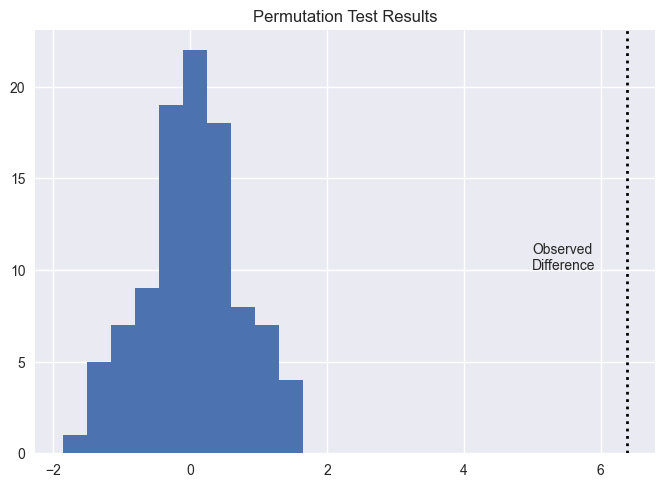

In [42]:
plt.hist(perms_diffs)
plt.axvline(obs_diff,color='black', lw=2, linestyle='dotted')
plt.text(5,10, 'Observed\nDifference')
plt.title('Permutation Test Results')
plt.show()

<h3> Calculate p-value. Given the histogram above, it should be straight 0.

In [36]:
np.mean(perms_diffs > obs_diff)

np.float64(0.0)

# What the permutation test did


From the observed result, I clearly saw that B had a higher mean than A by 6. But this could be by random chance.


So I ran a permutation test to see whether the results were random or not. This means I treated both A and B as the same by combing their results into one, then choosing from this new combined set a new A and new B, and calculated the difference of the new B's mean with the new A's mean.


The results of doing this is that these new mean values are far from the observed, as shown on the histogram. So this shows that the observed difference was real, that there really is a difference between A and B, not by random chance. Because if it were by random chance that B happened to be greater than A due to the subjects in each treatment, then by combining them, we should've got the same results as our observed (but we didn't).




# t-Test


Another type of significance testing, much less computational than a permutation test. 

Here I'll perform a one-sided Welch t-test.

In [37]:
from scipy import stats

In [38]:
# same arrays as before
A = np.array([
    52, 48, 55, 50, 49, 53, 51, 47, 54, 52,
    46, 50, 49, 51, 48, 52, 53, 47, 50, 49,
    54, 55, 51, 52, 48, 49, 50, 53, 47, 46,
    52, 54, 51, 49, 50, 48, 47, 53, 55, 52,
    49, 50, 51, 48, 46, 47, 52, 53, 54, 50,
    49, 51, 48, 47, 52, 53, 50, 49, 51, 48
])

B = np.array([
    56, 54, 58, 55, 57, 59, 56, 54, 57, 58,
    55, 56, 54, 57, 58, 59, 55, 56, 54, 57,
    58, 60, 59, 56, 55, 54, 57, 58, 56, 55,
    59, 60, 58, 57, 56, 55, 54, 59, 60, 58,
    57, 56, 55, 54, 58, 59, 57, 56, 55, 54,
    59, 60, 58, 57, 56, 55, 54, 59, 58, 57
])


Null Hypothesis: A.mean = B.mean . In other words, A and B are from the same population, random samples from it. 


Alternate hypothesis: B.mean > A.mean




In [39]:
t_stat, p_value = stats.ttest_ind(B, A, equal_var=False)

t_stat, p_value

(np.float64(15.999108068659186), np.float64(2.3351513739752846e-30))

For this example, given how different A and B are just by looking at them, it's clear that the p-value was going to be 0 (or extremely close to, like 2.3e-30).

A t-value has no built-in scale without context.


t = 2 with n = 10 is moderately interesting, but



t = 2 with n = 1,000 is extremely interesting.

So same t but very different meanings.

The p-value automatically accounts for sample size, uncertainty and reference distribution.


That is why decisions are made with p-values and not raw t-values.